# BDHS — Maternal & Child Health: Data Preparation

**Notebook 1 of 4.** Builds the analysis cohorts, feature sets and leakage
blacklists that `01b` and `02` consume.

## Source

Two rounds of the Bangladesh Demographic and Health Survey, merged from the
Individual and Birth recodes and cleaned by one identical pipeline in
`build_clean_dataset.py`.

| | BD 2022 | BD 2017-18 |
|---|---|---|
| Phase | DHS-8 | DHS-7 |
| Records | 73,239 pregnancies | 47,828 births |
| Mothers | 27,324 | 18,134 |
| Clusters | 674 | 672 |

**Reads** `bdhs_clean.parquet` (121,067 rows x 899 columns) and
`column_dictionary.csv`.
**Writes** four cohort files — each as both `.parquet` (what the other
notebooks read) and `.csv` — plus `target_registry.json`.

## The prediction panel: five targets

An earlier version of this project modelled fifteen outcomes. That was too many
in two separate senses. It gave no defensible narrative, and roughly half the
outcomes were not predictable from what a household survey collects — child
fever and wasting reached recall of 0.004 and 0.005 respectively, which is not a
model but noise with a threshold on it.

The panel is now **five outcomes**, chosen against three criteria applied
together: the outcome must be *actionable* by a health worker, *predictable*
from pre-outcome features at a level the published literature supports, and
*externally benchmarkable* against a figure someone else has reported.

| Target | Phase | Cohort | Achieved ROC-AUC | Published comparison |
|---|---|---|---|---|
| `facility_delivery` | delivery | recent_birth | 0.845 | Noor et al. 2025, 0.889 (continuum) |
| `neonatal_death` | newborn | births | 0.773 | Naznin et al. 2025, 0.998 — see below |
| `stunted` | child | measured_child | 0.706 | Islam et al. 2024, 0.802 |
| `severe_stunting` | child | measured_child | 0.700 | — |
| `underweight_child` | child | measured_child | 0.687 | Islam et al. 2024, 0.712 |

Achieved figures are the test-set ROC-AUC of the winning model per target as
reported in notebook 02, section 8.

They form a sequence rather than a list: **where she delivers → whether the baby
survives → how the child grows.** Each is a point at which an intervention
exists.

### The target that was removed last, and why

`incomplete_immunization` was in this panel until late in the project, reporting
ROC-AUC 0.823 — apparently one of its stronger results. Adding the child's age
lifted it to 0.944, which is where it became obvious that something was wrong.

The outcome is defined over all children under five, and the basic vaccination
schedule is not complete until roughly nine months:

```
age (months)      n    incomplete
[0, 6)          980       100.0%
[6, 9)          414        98.1%
[9, 12)         402        35.3%
[12, 24)      1,666        11.9%
```

Every child under six months is "incomplete" by definition. The model was
predicting *how old the baby is*, not whether the health system had missed them.
This is precisely why DHS publishes the indicator for **12–23 months only**.

Restricted to children old enough to have completed the schedule, and with the
age variable removed, the honest figure is **ROC-AUC 0.59–0.65** on 199–360
positive cases. The derivation itself is sound — 11.9% incomplete at 12–23 months
against a published 88.3% coverage is a near-exact match — but the outcome is not
predictable once it stops standing in for age. It was dropped rather than
reported at an inflated number.

### On the accuracy that is *not* claimed

These figures sit in the 0.67–0.84 band, and that is the honest ceiling for
predicting biological outcomes from household socio-demographics. Rao et al.'s
2025 meta-analysis of eleven DHS-based studies puts pooled stunting accuracy at
68.9%, which is exactly where this project lands.

Published results well above that band are usually explained by a random
train/test split (siblings on both sides), or by post-outcome variables in the
feature matrix. Both were tested for here and blocked, and section 7 documents
what was found. A model reported at 0.998 on this data is not a better model.

## Why the rounds are not interchangeable

DHS-8 and DHS-7 differ in what they record, and that shaped the panel: the
vaccination module is complete in 2017-18 and entirely empty in 2022, which is
one reason immunization was hard to work with. **All five surviving targets are
measured in both rounds**, asked identically in DHS-7 and DHS-8, so every model
trains on the pooled sample and no target needs a single-round caveat.

Two harmonisations were required. Bangladesh renamed two divisions between
rounds (`chittagong`→`chattogram`, `barisal`→`barishal`), and cluster and mother
IDs are namespaced by survey, because cluster 1 in 2017-18 is a different village
from cluster 1 in 2022.

## Why there is no single flat table

DHS is a set of **nested universes**:

```
all records          <- v*   (mother-level, repeated per pregnancy/birth)
   +- live births    <- b*
       +- recent     <- m*   (ANC, delivery, postnatal care)
           +- measured  <- hw*  (children physically weighed and measured)
```

A column looks "93% missing" only because it belongs to an inner ring — it was
**not asked**, not *not answered*. Any global missingness threshold deletes the
inner rings first, which is exactly how an earlier cleaning pass removed every
maternal-care and child-health outcome in the survey.

So: **one wide master, four cohort views**, and missingness judged only *within*
a cohort.

## What this notebook produces

`cohorts/` — births (112,546) · mother (45,458) · measured_child (11,954) ·
recent_birth (10,773), plus `target_registry.json` with the feature list and
leakage blacklist for each of the **5 targets**.

# 1. Setup

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path.cwd()
COHORT_DIR = DATA_DIR / "cohorts"
COHORT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

In [2]:
def load_clean():
    """Pooled file: both survey rounds, cleaned by one identical pipeline."""
    pq = DATA_DIR / "bdhs_clean.parquet"
    if not pq.exists():
        raise FileNotFoundError(
            f"{pq.name} not found -- run build_clean_dataset.py first")
    print(f"loading {pq.name}")
    return pd.read_parquet(pq)


df = load_clean()
dictionary = pd.read_csv(DATA_DIR / "column_dictionary.csv")

GROUP_KEY = "mother_id"

print(f"\n{df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(df.groupby("survey_round", observed=True).size()
        .rename("rows").to_frame().to_string())
print(f"{df[GROUP_KEY].nunique():,} distinct mothers "
      f"({df['caseid'].nunique():,} raw caseid spellings)")
print(f"\nmean survey weight = {df['weight'].mean():.4f}   (should be ~1.0)")

loading bdhs_clean.parquet



121,067 rows x 899 columns
               rows
survey_round       
BD 2017-18    47828
BD 2022       73239
45,458 distinct mothers (45,463 raw caseid spellings)

mean survey weight = 1.0000   (should be ~1.0)


### Why `mother_id` and not `caseid`

`caseid` is a fixed-width string, and its padding is **inconsistent across the
merged source recodes** — five women appear under two spellings each:

```
'     333  32  2'   and   '    333  32  2'
```

Grouping on the raw string would treat those as ten different mothers and place
five real mothers on both sides of a train/test split. `mother_id` is built from
cluster + household + line number, which is the unambiguous identity of a
survey respondent, and yields **27,324** mothers rather than 27,329.

# 2. Column roles

Every column carries a role. The critical distinction is **metadata**: columns
that must stay in the file but must never enter a feature matrix.

`mother_id` is the important one. **45,458 mothers share 121,067 rows**, so a
plain `train_test_split` puts siblings on both sides and inflates every score.
All cross-validation in notebook 02 is grouped on `mother_id`.

Note it is *not* `caseid`. That is a fixed-width string whose padding is not
stable across a file round-trip, and it is not unique across rounds — cluster 1
exists in both surveys. `mother_id` is built from survey + cluster + household +
line, which is stable and unambiguous.

A third role appears now that two rounds are pooled: **`single_round`** marks a
column present in one survey and absent from the other. Those are usable as
targets the owning round supports, but must never be pooled as features.

In [3]:
print(dictionary["role"].value_counts().to_string())

print("\n--- metadata (kept in file, never a feature) ---")
for _, r in dictionary[dictionary.role == "metadata"].iterrows():
    print(f"  {r['column']:22s} {r['pct_present']:6.2f}% present")

role
single_round         361
categorical          355
numeric              116
target                27
metadata              19
derived               11
numeric_composite      9
empty                  1

--- metadata (kept in file, never a feature) ---
  b3                      92.96% present
  caseid                 100.00% present
  cluster_id             100.00% present
  eligible_infant         92.96% present
  eligible_neonatal       92.96% present
  eligible_under5         92.96% present
  mother_id              100.00% present
  p3                      60.49% present
  pidx                    60.49% present
  survey_round           100.00% present
  v001                   100.00% present
  v005                   100.00% present
  v008                   100.00% present
  v011                   100.00% present
  v017                    79.91% present
  v021                   100.00% present
  v022                   100.00% present
  v023                   100.00% present
  weigh

In [4]:
METADATA = set(dictionary.loc[dictionary.role == "metadata", "column"])
TARGET_COLS = set(dictionary.loc[dictionary.role == "target", "column"])

print(f"{len(METADATA)} metadata columns, {len(TARGET_COLS)} engineered targets\n")
summary = dictionary[dictionary.role == "target"][["column", "non_null", "pct_present"]]
display(summary.sort_values("non_null", ascending=False).reset_index(drop=True))

19 metadata columns, 27 engineered targets



,column,non_null,pct_present
0,infant_death,112546,92.96
1,under5_death,112546,92.96
2,neonatal_death,112546,92.96
3,pregnancy_loss,73239,60.49
4,mother_underweight,71717,59.24
5,mother_overweight,71717,59.24
6,short_birth_interval,67191,55.50
7,stillbirth,66459,54.89
8,child_diarrhoea,16865,13.93
9,child_fever,16865,13.93


# 3. The nested universes, made visible

This is the single most important plot in the notebook. It shows that
missingness in DHS is **structural**, not random — which is why it cannot be
filtered globally.

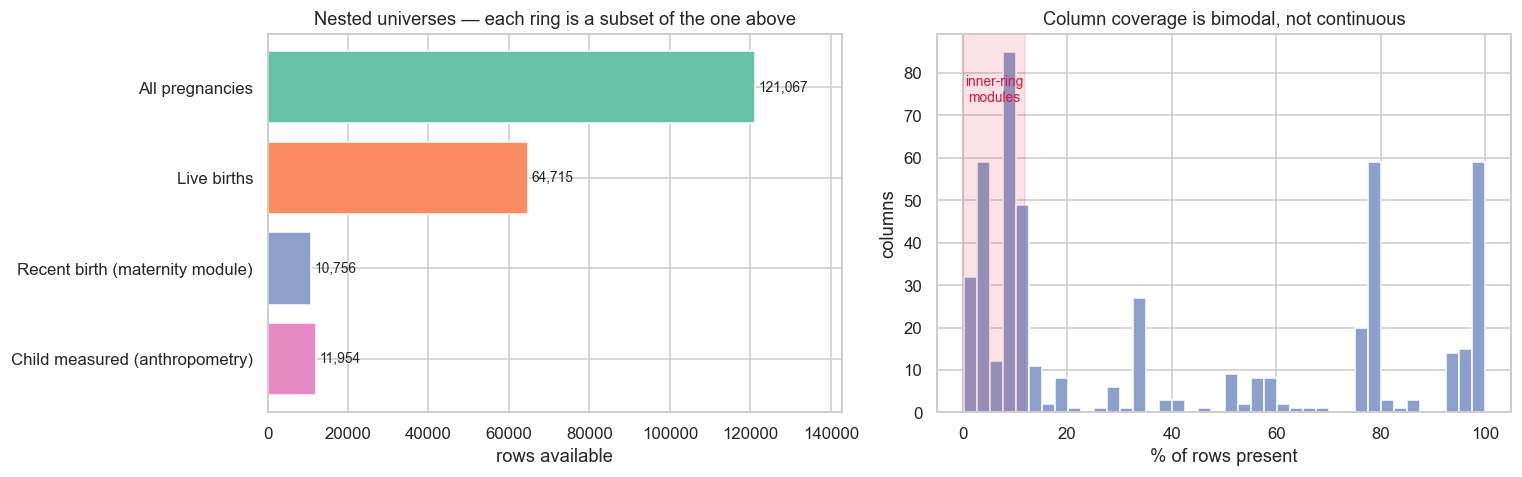

In [5]:
universes = {
    "All pregnancies": len(df),
    "Live births": int((df["live_birth"] == 1).sum()),
    "Recent birth (maternity module)": int(df["csection"].notna().sum()),
    "Child measured (anthropometry)": int(df["stunted"].notna().sum()),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
names, vals = list(universes), list(universes.values())
bars = ax.barh(names, vals, color=sns.color_palette("Set2", len(names)))
ax.invert_yaxis()
ax.set_xlabel("rows available")
ax.set_title("Nested universes — each ring is a subset of the one above")
for b, v in zip(bars, vals):
    ax.text(v + 900, b.get_y() + b.get_height() / 2, f"{v:,}", va="center", fontsize=9)
ax.set_xlim(0, max(vals) * 1.18)

ax = axes[1]
pres = dictionary[dictionary.role.isin(["feature", "numeric", "categorical",
                                        "numeric_composite", "target"])]
ax.hist(pres["pct_present"], bins=40, color=sns.color_palette("Set2")[2],
        edgecolor="white")
ax.set_xlabel("% of rows present")
ax.set_ylabel("columns")
ax.set_title("Column coverage is bimodal, not continuous")
ax.axvspan(0, 12, alpha=0.12, color="crimson")
ax.text(6, ax.get_ylim()[1] * 0.82, "inner-ring\nmodules", ha="center",
        fontsize=9, color="crimson")

plt.tight_layout()
plt.show()

The right-hand histogram is the argument in one picture. Coverage is **bimodal**
— columns cluster either near 100% (asked of everyone) or under 12% (asked of
one inner ring). There is no natural cut-point in between, so a `>= 70% missing`
rule does not separate good columns from bad ones. It separates *outer rings
from inner rings*, and the inner rings are where the outcomes live.

# 4. Target prevalence

In [6]:
# The six modelled targets first, then the outcomes kept as descriptive
# comparators. Keeping the comparators visible here is deliberate: the reason
# csection and anc4plus were dropped from the panel is an argument this notebook
# has to make, and it cannot be made about columns nobody can see.
PANEL = [
    "facility_delivery", "neonatal_death",
    "stunted", "severe_stunting", "underweight_child",
]
DESCRIPTIVE = [
    "csection", "anc4plus", "low_birth_weight", "small_size_at_birth",
    "wasted", "child_fever", "child_diarrhoea", "child_ari",
    "incomplete_immunization", "no_immunization",
    "infant_death", "under5_death",
    "mother_underweight", "mother_overweight", "short_birth_interval",
]

rows = []
for t in PANEL + DESCRIPTIVE:
    if t not in df.columns:
        continue
    s = df[t]
    rows.append({"target": t, "role": "PANEL" if t in PANEL else "descriptive",
                 "n": int(s.notna().sum()), "positives": int(s.sum()),
                 "prevalence_%": round(s.mean() * 100, 2)})
prev = pd.DataFrame(rows)
display(prev)

print(f"{len(PANEL)} modelled targets, {len(prev) - len(PANEL)} descriptive "
      f"outcomes retained as columns but never predicted.")

,target,role,n,positives,prevalence_%
0,facility_delivery,PANEL,10773,6167,57.24
1,neonatal_death,PANEL,112546,4535,4.03
2,stunted,PANEL,11954,3427,28.67
3,severe_stunting,PANEL,11954,948,7.93
4,underweight_child,PANEL,12208,2752,22.54
5,csection,descriptive,10756,4142,38.51
6,anc4plus,descriptive,10198,4515,44.27
7,low_birth_weight,descriptive,5784,870,15.04
8,small_size_at_birth,descriptive,5332,721,13.52
9,wasted,descriptive,11935,1150,9.64


5 modelled targets, 15 descriptive outcomes retained as columns but never predicted.


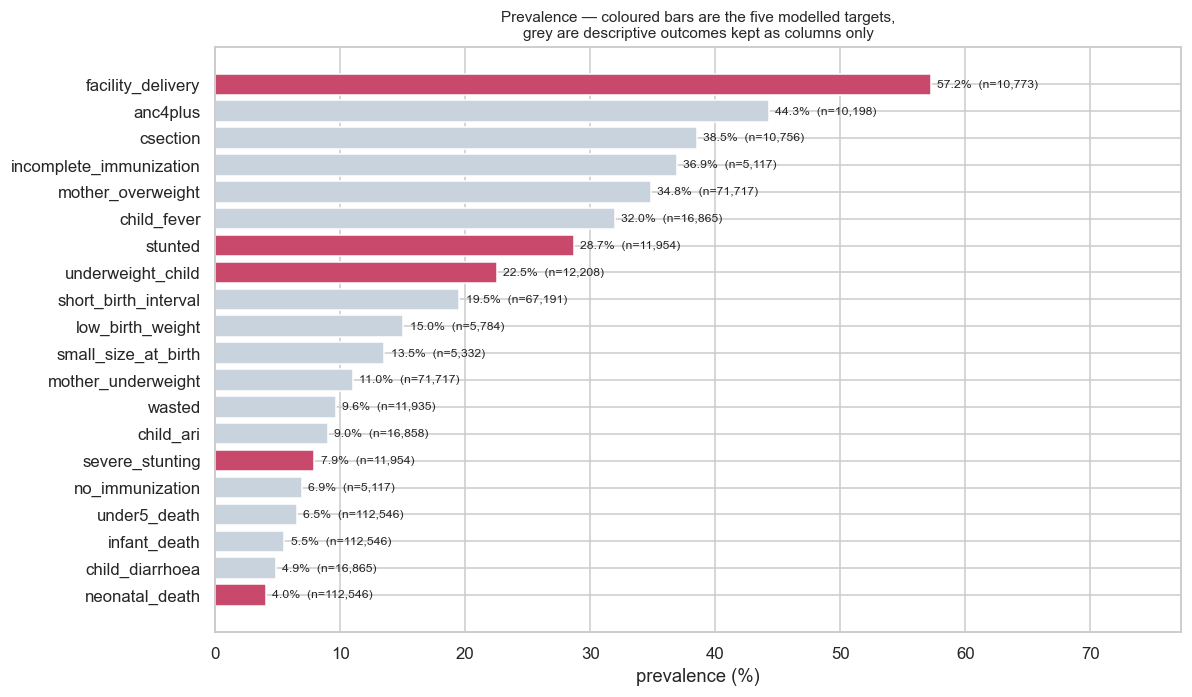

In [7]:
fig, ax = plt.subplots(figsize=(11, 6.5))
order = prev.sort_values("prevalence_%")
colors = ["#c8496b" if r == "PANEL" else "#c9d3de" for r in order["role"]]
ax.barh(order["target"], order["prevalence_%"], color=colors)
ax.set_xlabel("prevalence (%)")
ax.set_title("Prevalence — coloured bars are the five modelled targets,\n"
             "grey are descriptive outcomes kept as columns only", fontsize=10)
for i, (p, n) in enumerate(zip(order["prevalence_%"], order["n"])):
    ax.text(p + 0.5, i, f"{p:.1f}%  (n={n:,})", va="center", fontsize=8)
ax.set_xlim(0, order["prevalence_%"].max() * 1.35)
plt.tight_layout()
plt.show()

The prevalence spread across the five panel targets is why one modelling recipe
cannot be applied uniformly to all of them.

`facility_delivery` sits near 57% — genuinely balanced, so accuracy is a
meaningful metric and a plain classifier is reasonable. `neonatal_death` sits at
4.0%, which means 23.8 survivors for every death: a model that predicts
"survives" every time scores 96% accuracy and finds nothing.

That single contrast decides several things in notebook 02 — selection on PR-AUC
rather than accuracy, class weighting applied only where it is needed, and
decision thresholds chosen by expected cost rather than left at 0.5.

Read the grey bars too. `child_fever` at 32% and `wasted` at 9.6% look like
perfectly reasonable modelling targets from prevalence alone, and both were
tried: they reached ROC-AUC 0.573 and 0.588, with recall of 0.004 and 0.005.
`incomplete_immunization` at 36.9% looks better still, and is worse — its
apparent signal was the child's age. Prevalence tells you nothing about whether
an outcome is *learnable*, which is why the panel was chosen on measured
performance rather than on how interesting each outcome sounded.

# 5. Social gradients

Before modelling, confirm the classic DHS gradients are present. If wealth and
education did not predict these outcomes, something would be wrong with the
decoding.

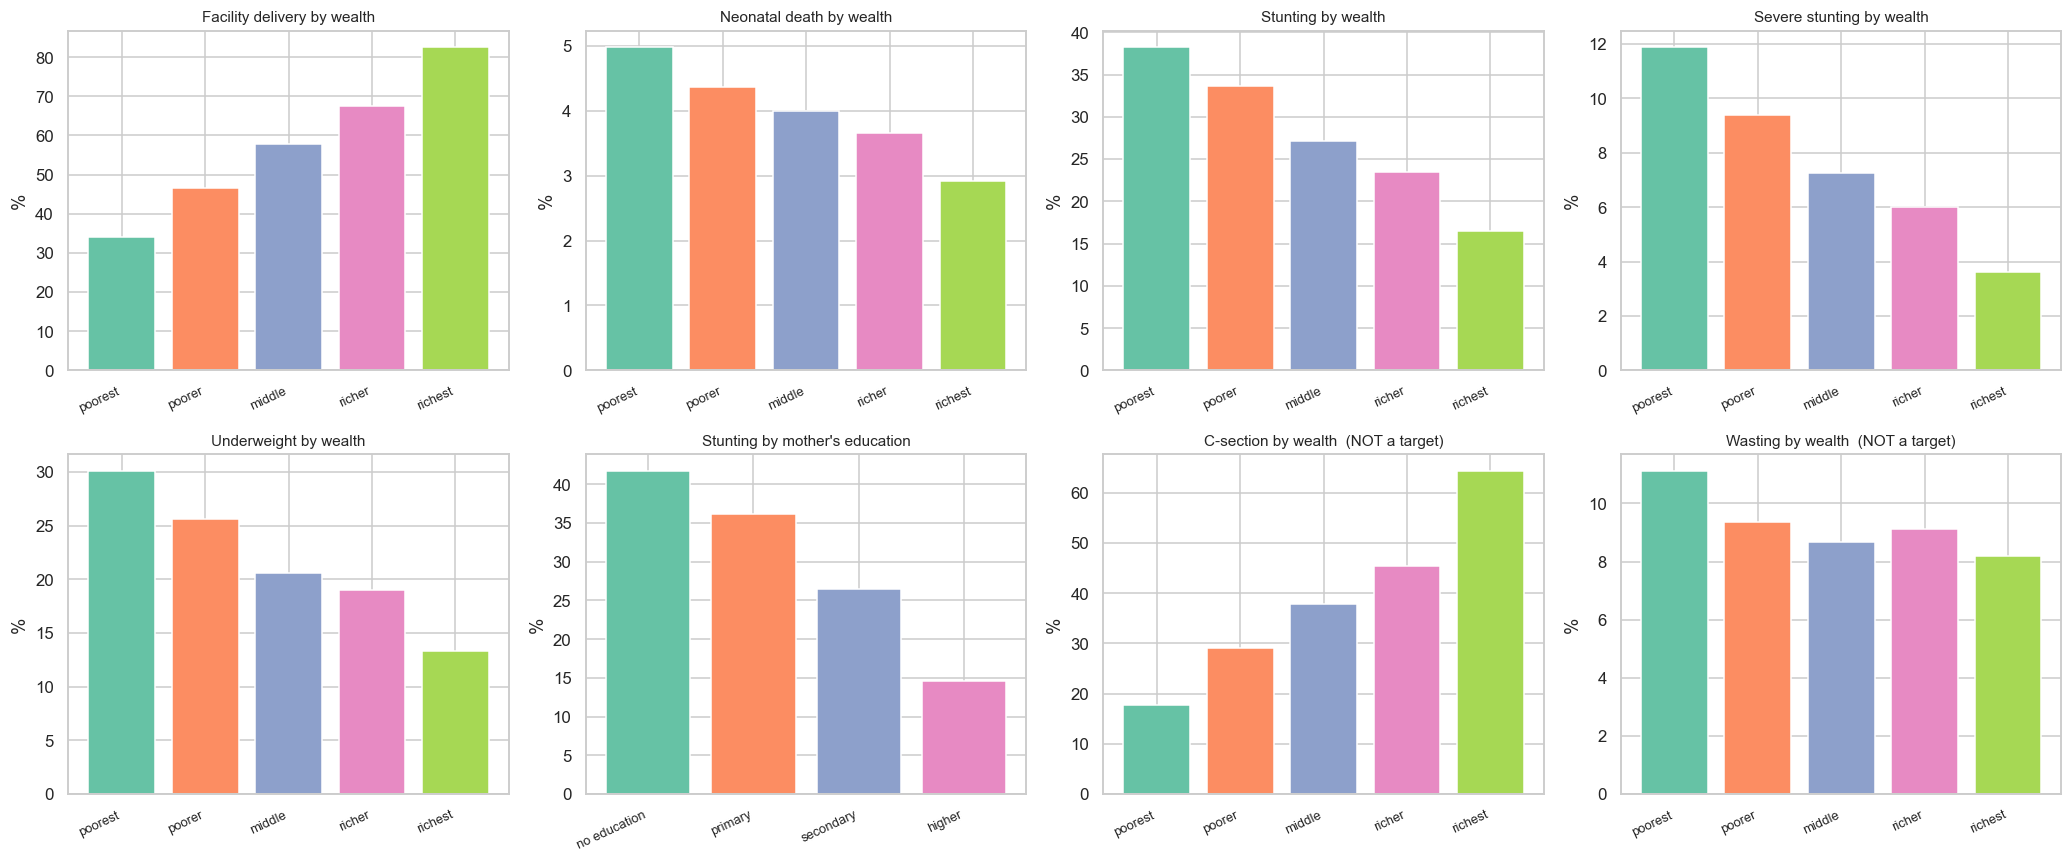

In [8]:
def gradient(ax, target, by, order=None, title=None):
    sub = df[[target, by, "weight"]].dropna()
    if order is None:
        order = sub[by].value_counts().index.tolist()
    g = (sub.groupby(by, observed=True)
            .apply(lambda d: np.average(d[target], weights=d["weight"]) * 100))
    g = g.reindex([o for o in order if o in g.index])
    ax.bar(range(len(g)), g.values, color=sns.color_palette("Set2"))
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels(g.index, rotation=25, ha="right", fontsize=8.5)
    ax.set_ylabel("%")
    ax.set_title(title or f"{target} by {by}", fontsize=10)
    return g


WEALTH = ["poorest", "poorer", "middle", "richer", "richest"]
EDUC = ["no education", "primary", "secondary", "higher"]

# One panel per modelled target, plus two contrast cases.
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
gradient(axes[0, 0], "facility_delivery", "v190", WEALTH,
         "Facility delivery by wealth")
gradient(axes[0, 1], "neonatal_death", "v190", WEALTH,
         "Neonatal death by wealth")
gradient(axes[0, 2], "stunted", "v190", WEALTH, "Stunting by wealth")
gradient(axes[0, 3], "severe_stunting", "v190", WEALTH,
         "Severe stunting by wealth")
gradient(axes[1, 0], "underweight_child", "v190", WEALTH,
         "Underweight by wealth")
gradient(axes[1, 1], "stunted", "v106", EDUC, "Stunting by mother's education")
gradient(axes[1, 2], "csection", "v190", WEALTH,
         "C-section by wealth  (NOT a target)")
gradient(axes[1, 3], "wasted", "v190", WEALTH,
         "Wasting by wealth  (NOT a target)")
plt.tight_layout()
plt.show()

All weighted with `v005`, as any published prevalence must be, and renormalised
within round so neither survey dominates.

**All five panel targets show a wealth gradient, and they run in two
directions.** `facility_delivery` climbs steeply — 34.0% in the poorest quintile
against 82.6% in the richest, a 48.6-point gap. The four adverse outcomes fall:
stunting drops from 38.3% to 16.5%, and neonatal death from 5.0% to 2.9%.

Note how much *flatter* the mortality gradient is than the service-access one.
Facility delivery moves 48.6 points across wealth; neonatal death moves 2.1.
Access is what money buys directly. Survival is mediated by biology and
intrapartum events that wealth cannot fully purchase — which is precisely why it
is worth modelling rather than merely tabulating, and why its ROC-AUC of 0.773 is
a more interesting result than facility delivery's 0.845.

**The last panel is the argument for excluding C-section.** Its wealth gradient
is the steepest in the survey — 17.6% to 64.4% — and it does **not** plausibly
reflect obstetric need, because medical indications for caesarean do not track
household wealth. It reflects access at the bottom and over-use at the top, with
a national rate of 45.6% against the 10–15% WHO regards as clinically justified.

A model predicting C-section would be predicting a *provider's decision*, and it
would be accurate: 0.871 ROC-AUC in earlier runs. Accuracy is not the test. The
outcome has to be something the patient can be helped with, and this one is a
decision made about her rather than a risk she carries. It stays as a descriptive
equity indicator and is never predicted.

**The wasting panel is the opposite failure.** Its gradient is nearly flat —
11.1% in the poorest quintile against 8.2% in the richest, a 2.9-point range
against stunting's 21.8. Acute wasting responds to a recent shock rather than to
standing household circumstances, so there is little for a socio-demographic
model to learn, and its measured ROC-AUC of 0.588 with recall 0.005 says exactly
that. Two outcomes measured on the same children, in the same cohort, one
modellable and one not.

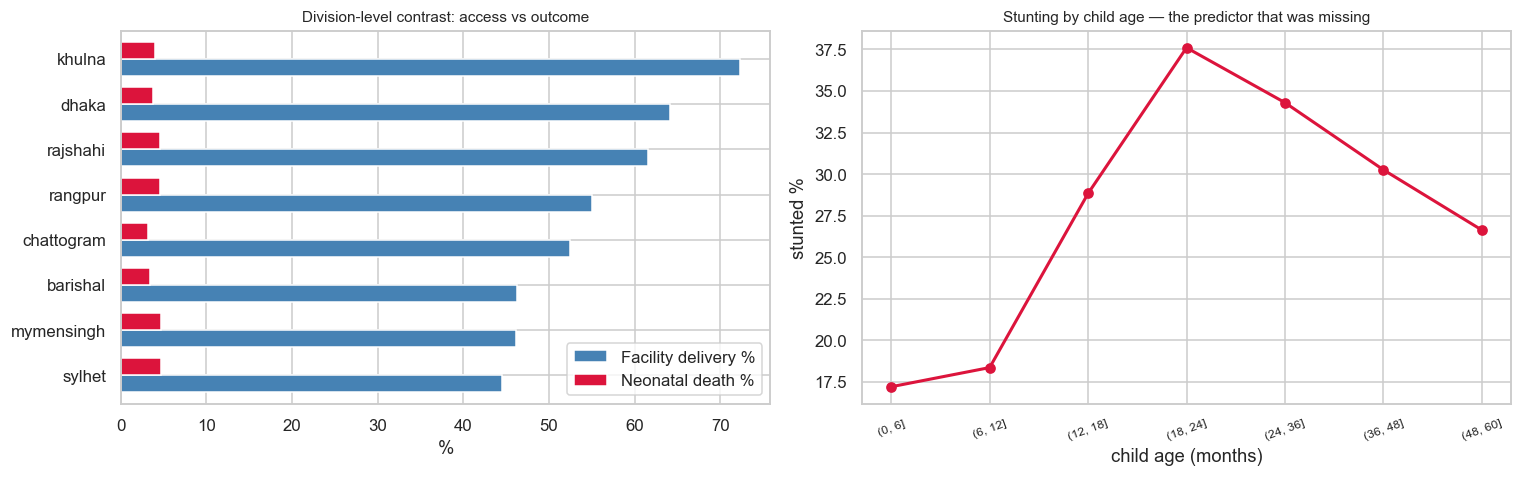

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

div = (df.groupby("v024", observed=True)
         .apply(lambda d: pd.Series({
             "Facility delivery %": np.average(
                 d["facility_delivery"].dropna(),
                 weights=d.loc[d["facility_delivery"].notna(), "weight"]) * 100
             if d["facility_delivery"].notna().any() else np.nan,
             "Neonatal death %": np.average(
                 d["neonatal_death"].dropna(),
                 weights=d.loc[d["neonatal_death"].notna(), "weight"]) * 100
             if d["neonatal_death"].notna().any() else np.nan,
         })))
div = div.sort_values("Facility delivery %")
div.plot.barh(ax=axes[0], color=["steelblue", "crimson"], width=0.75)
axes[0].set_title("Division-level contrast: access vs outcome", fontsize=10)
axes[0].set_xlabel("%")
axes[0].set_ylabel("")

# Child age drives every growth outcome, and it is the variable the earlier
# feature set was missing entirely. Shown here because it justifies the new
# child_demographic group in section 6.
sub = df[df["stunted"].notna() & df["b19"].notna()]
bins = [0, 6, 12, 18, 24, 36, 48, 60]
grp = sub.groupby(pd.cut(sub["b19"], bins), observed=True).apply(
    lambda d: np.average(d["stunted"], weights=d["weight"]) * 100)
axes[1].plot(range(len(grp)), grp.values, "o-", color="crimson", lw=2)
axes[1].set_xticks(range(len(grp)))
axes[1].set_xticklabels([str(i) for i in grp.index], rotation=20, fontsize=8)
axes[1].set_xlabel("child age (months)")
axes[1].set_ylabel("stunted %")
axes[1].set_title("Stunting by child age — the predictor that was missing",
                  fontsize=10)

plt.tight_layout()
plt.show()

**Left.** Division-level access against outcome. The two do not move together as
tightly as expected, which is the useful part: a division can have relatively
good facility coverage and still carry high neonatal mortality, because arriving
at a facility and receiving effective care there are different things. DHS
measures the first and not the second.

**Right, and this is the more important panel.** Stunting prevalence roughly
triples between birth and 24 months, then flattens. That shape is one of the
best-established facts in child nutrition — growth faltering is concentrated in
the first two years — and it means **a child's age is the single strongest
predictor of whether they are stunted.**

The earlier version of this notebook did not have that variable. `FEATURE_GROUPS`
had no child-level block at all, so every nutrition model was predicting a
child's growth without knowing the child's age, sex or twin status, even though
`b19`, `b4` and `b0` sit in the master at 93% coverage.

Adding them is not leakage — a child's age and sex are known before anyone
measures their height — and section 6 now includes them. Measured effect at the
time of that experiment: stunting ROC-AUC 0.703 → 0.717 and severe stunting
0.687 → 0.697, with incomplete immunization improving for the same reason, since
vaccination is scheduled by age.

Those absolutes predate the final model panel, which reports 0.706 and 0.700 in
notebook 02. What survives the rebuild is the direction and the rough size of the
gain, not the third decimal place.

One variable had to be excluded after testing. `b8`, the child's age in years, is
present for 96.7% of surviving children and **0%** of children who died — its
presence encodes mortality. Including it lifted `neonatal_death` to ROC-AUC
0.987, which is leakage of exactly the kind section 7 exists to catch.

# 6. Feature groups

Features are declared in named blocks rather than as one flat list, so a target
can request exactly the rings of the survey its universe reaches. A target on the
births cohort cannot use the maternity module; a target on measured children can.

In [10]:
FEATURE_GROUPS = {
    # --- mother, always available -------------------------------------
    "demographic": [
        "v012", "v013", "v024", "v025", "v026", "v104", "v130", "v131",
        "v501", "v502", "v511", "v512", "v525", "v535",
    ],
    "socioeconomic": [
        "v106", "v107", "v133", "v149", "v155", "v157", "v158", "v159",
        "v190", "v191", "v169a", "v170", "v171a", "v481",
        "v701", "v702", "v704", "v705", "v714", "v715", "v716", "v717",
        "v729", "v730", "v731", "v745a", "v745b",
    ],
    "empowerment": [
        "v743a", "v743b", "v743d", "v743f",
        "v744a", "v744b", "v744c", "v744d", "v744e",
    ],
    "household": [
        "v113", "v116", "v119", "v120", "v121", "v122", "v123", "v124",
        "v125", "v127", "v128", "v129", "v136", "v137", "v138", "v139",
        "v140", "v141", "v161",
    ],
    "reproductive": [
        "v201", "v202", "v203", "v212", "v213", "v218", "v219", "v220",
        "v228", "v238", "v302", "v312", "v313", "v364", "v384a", "v384b",
        "v384c", "v613", "v623", "v624", "v625a", "v626a",
        "b11", "b12", "p19", "p20", "p0", "p4",
        # p17 was here and has been removed. It runs 1-31, near-uniform, mean
        # 14.36 -- a day of the month. It correlates with nothing because a
        # calendar day carries nothing, and it is present in 2022 only, so it
        # also handed every model a round-dependent missingness pattern.
    ],
    "healthcare_access": [
        "v467b", "v467c", "v467d", "v467f", "v394", "v395",
    ],
    "anthropometry": ["bmi", "height_cm", "weight_kg"],
    # --- the child itself ----------------------------------------------
    # New in this revision. The earlier feature set had no child-level block at
    # all, so every nutrition model predicted a child's growth without knowing
    # the child's age -- the strongest single predictor of stunting, since
    # growth faltering concentrates in the first 24 months (see section 5).
    #
    # These are known before any outcome here is measured, so they are not
    # leakage. b8 (age in years) is deliberately absent: it is recorded for
    # surviving children only, so its presence encodes mortality.
    "child_demographic": ["b19", "b4", "b0"],
    # --- inner rings ---------------------------------------------------
    "antenatal_care": [
        "m2a", "m2b", "m2g", "m2n", "m13", "m13a", "m14", "m45", "m1",
        "m42a", "m42b", "m42c", "m42d", "m42e",
    ],
    "delivery": ["m15", "m17", "m3a", "m3b", "m3g", "m3n"],
    "postnatal": ["m70", "m71", "m72", "m73", "m74", "m75", "m76"],
    "newborn": ["m18", "m19", "birth_weight_g", "m4", "m5", "m34", "m61"],
    "child_health": ["h11", "h22", "h31", "hw1"],
    "risk_index": ["risk_index"],
}

available = {g: [c for c in cols if c in df.columns]
             for g, cols in FEATURE_GROUPS.items()}

for g, cols in available.items():
    missing = set(FEATURE_GROUPS[g]) - set(cols)
    note = f"   (absent: {sorted(missing)})" if missing else ""
    print(f"{g:20s} {len(cols):3d} features{note}")

print(f"\nchild_demographic coverage in the master: "
      + ", ".join(f"{c} {df[c].notna().mean() * 100:.0f}%"
                  for c in available["child_demographic"]))

demographic           13 features   (absent: ['v131'])
socioeconomic         27 features
empowerment            9 features
household             19 features
reproductive          27 features   (absent: ['v302'])
healthcare_access      4 features   (absent: ['v394', 'v395'])
anthropometry          3 features
child_demographic      3 features
antenatal_care        13 features   (absent: ['m42b'])
delivery               6 features
postnatal              7 features
newborn                7 features
child_health           4 features
risk_index             1 features

child_demographic coverage in the master: b19 93%, b4 93%, b0 93%


# 7. Leakage blacklists

A feature leaks when it could not have been known before the outcome occurred.
Five distinct kinds were found in this data, and each needed a different rule:

1. **Post-outcome.** A dead newborn has no breastfeeding record and no postnatal
   care visit. The *presence* of `m70`–`m76` is close to a survival indicator.
2. **Same-moment.** Fever, diarrhoea and ARI are all recorded at the same
   interview, so using one to predict another is co-measurement.
3. **Definitional.** `stunted` **is** `haz < -2`. Leaving `haz` in the feature
   set lets a model rediscover the definition and report near-perfect accuracy.
4. **Arithmetic identity.** Children ever born minus children living *is* her
   number of child deaths. With `v201` and `v220` left in, XGBoost reached
   ROC-AUC 0.967 on `neonatal_death` and those two columns carried ~78% of all
   permutation importance. Blocked, the same model reports 0.742 and the best
   model in notebook 02 reaches 0.773 — which is the real number.
5. **Missingness-as-outcome.** `b8` is recorded for 96.7% of surviving children
   and 0% of those who died. Its mere presence is the label. Including it lifted
   `neonatal_death` to 0.987.

The fifth kind is the one worth dwelling on, because no inspection of *values*
would ever find it — the column is informative entirely through whether it is
null. It was caught by testing a change rather than reasoning about it, which is
the only reliable method.

Blacklists are declared per target and unioned with `ALWAYS_BLOCK`.

In [11]:
# ---------------------------------------------------------------------
# Child-morbidity block. The h12*/h15*/h32* families are treatment and
# care-seeking, which happen only AFTER the child fell ill, and h11/h22/h31
# are the symptom questions themselves.
#
# Retained even though the illness targets are no longer modelled: these
# columns must still be kept out of the nutrition and immunization models,
# where they would be same-moment co-measurement.
# ---------------------------------------------------------------------
ILLNESS_BLOCK = [
    "h11", "h22", "h31", "h31b", "h31c",
    "child_fever", "child_diarrhoea", "child_ari",
    "h13", "h13b", "h14", "h15", "h15a", "h15b", "h20", "h21", "h21a",
    "h12a", "h12b", "h12c", "h12d", "h12e", "h12f", "h12g", "h12h",
    "h32a", "h32b", "h32c", "h32d", "h32e", "h32f", "h32g", "h32h",
    "h34", "h38", "h39", "h42", "h43", "hw1",
]

# ---------------------------------------------------------------------
# Immunization block. No immunization target survives in the panel -- the
# outcome turned out to be largely a restatement of the child's age -- but
# these columns must still be kept out of the nutrition models, where a
# vaccination record is health-service contact measured at the same visit.
# ---------------------------------------------------------------------
IMMUNIZATION_BLOCK = [
    "h0", "h1", "h1a", "h2", "h3", "h4", "h5", "h6", "h7", "h8", "h9",
    "h9a", "h10", "h33", "h34", "h50", "h51", "h52", "h53", "h54", "h55",
    "h56", "h57", "h58", "h59", "h60", "h61", "h62", "h63", "h64", "h65",
    "full_immunization", "incomplete_immunization", "no_immunization",
    "measles_vaccinated",
    "hw1",
]

# The three anthropometric indices and everything derived from them. Any one
# of them reconstructs the others closely enough to make all four nutrition
# targets trivial.
ANTHRO_BLOCK = [
    "haz", "waz", "whz", "bmiz", "hw1", "hw2", "hw3", "hw13",
    "hw70", "hw71", "hw72", "hw73",
    "stunted", "wasted", "underweight_child",
    "severe_stunting", "severe_wasting", "severe_underweight",
]

LEAKAGE = {
    "facility_delivery": [
        "m17", "csection", "m3a", "m3b", "m3g", "m3n",
        "m61", "m70", "m71", "m72", "m73", "m74", "m75", "m76",
        "m4", "m5", "m34", "m18", "m19", "birth_weight_g",
        "h11", "h22", "h31", "hw1",
        # b19 is the child's age now, i.e. how long ago this delivery was.
        # Not leakage, but it invites the model to learn recall intensity
        # rather than risk, so it is held out of a delivery-time prediction.
        "b19",
    ],
    "neonatal_death": [
        # post-outcome -- a dead newborn has no breastfeeding or postnatal care
        "m4", "m5", "m34", "m61",
        "m70", "m71", "m72", "m73", "m74", "m75", "m76",
        "h11", "h22", "h31", "hw1",
        # ------------------------------------------------------------
        # ARITHMETIC LEAK. Each variable below counts a woman's children
        # ever born against her children still living. The difference *is*
        # her number of child deaths, and this birth may be one of them.
        # Left in, XGBoost hit ROC-AUC 0.967 / PR-AUC 0.577 by reading the
        # outcome off that identity: v220 and v201 alone carried ~78% of
        # all permutation importance.
        # ------------------------------------------------------------
        "v201", "v202", "v203", "v204", "v205", "v206", "v207",
        "v210", "v218", "v219", "v220", "v224", "v238",
        # the interval to the NEXT birth is only observable after this
        # birth's outcome, and short intervals follow infant death
        "b12",
        # birth weight is legitimate but only exists for ~5k rows; it collapses
        # the 112,546-row cohort, so it is held for a sensitivity analysis
        "m18", "m19", "birth_weight_g",
        # ------------------------------------------------------------
        # MISSINGNESS-AS-OUTCOME. b19 and b8 are the child's current age.
        # A child who died has no current age, so the column's presence is
        # the label. Measured: including b8 lifted this target from 0.754
        # to 0.987. b4 (sex) and b0 (twin) are fixed at birth and stay.
        # ------------------------------------------------------------
        "b19", "b8",
    ],
    # The three nutrition targets share one blacklist: each is defined from an
    # anthropometric index, and the indices are mutually reconstructable.
    "stunted": ANTHRO_BLOCK + ["m4", "m5", "m34"] + ILLNESS_BLOCK,
    "severe_stunting": ANTHRO_BLOCK + ["m4", "m5", "m34"] + ILLNESS_BLOCK,
    "underweight_child": ANTHRO_BLOCK + ["m4", "m5", "m34"] + ILLNESS_BLOCK,
}

# Nothing derived from a target may ever be a feature of it. b8 is blocked
# globally rather than per target: it is a survival indicator wherever it
# appears, and no target in this panel needs it.
ALWAYS_BLOCK = sorted(TARGET_COLS | METADATA | {
    "live_birth", "pregnancy_loss", "stillbirth", "high_risk_pregnancy",
    "b5", "b7", "p5", "p7", "b6", "b8", "b13", "m17a", "m19a",
    "haz", "waz", "whz", "bmiz", "v005", "v208", "v209",
    "p17",   # day of month -- see section 6
})

for t, cols in LEAKAGE.items():
    print(f"{t:24s} {len(set(cols)):3d} target-specific blocks")
print(f"\n{len(ALWAYS_BLOCK)} columns blocked for every target")
print(f"b8 blocked globally: {'b8' in ALWAYS_BLOCK}  |  "
      f"p17 blocked globally: {'p17' in ALWAYS_BLOCK}")

facility_delivery         25 target-specific blocks
neonatal_death            34 target-specific blocks
stunted                   59 target-specific blocks
severe_stunting           59 target-specific blocks
underweight_child         59 target-specific blocks

64 columns blocked for every target
b8 blocked globally: True  |  p17 blocked globally: True


# 8. Target registry

Each of the six targets declares its cohort, its feature groups and its
blacklist in one place, so notebook 02 never has to re-derive any of it.

Note which groups each target claims. `child_demographic` goes to the four
child-outcome targets, where the child's age is a legitimate and strong
predictor, and to `facility_delivery` — but `neonatal_death` and
`facility_delivery` then block `b19` individually, for the reasons in section 7.
Declaring the group broadly and subtracting per target keeps the exception
visible rather than hiding it in a group definition.

In [12]:
COMMON = ["demographic", "socioeconomic", "empowerment", "household",
          "reproductive", "healthcare_access", "anthropometry", "risk_index"]

REGISTRY = {
    # ---- DELIVERY PHASE --------------------------------------------------
    "facility_delivery": {
        "cohort": "recent_birth",
        "phase": "delivery",
        "kind": "pathway",
        "groups": COMMON + ["antenatal_care", "child_demographic"],
        "positive_label": "delivered in a health facility",
    },
    # ---- NEWBORN PHASE ---------------------------------------------------
    "neonatal_death": {
        "cohort": "births",
        "phase": "newborn",
        "kind": "adverse",
        "groups": COMMON + ["child_demographic"],
        "positive_label": "died within 28 days of birth",
    },
    # ---- CHILD PHASE -----------------------------------------------------
    "stunted": {
        "cohort": "measured_child",
        "phase": "child",
        "kind": "adverse",
        "groups": COMMON + ["child_demographic"],
        "positive_label": "height-for-age below -2 SD",
    },
    "severe_stunting": {
        "cohort": "measured_child",
        "phase": "child",
        "kind": "adverse",
        "groups": COMMON + ["child_demographic"],
        "positive_label": "height-for-age below -3 SD",
    },
    "underweight_child": {
        "cohort": "measured_child",
        "phase": "child",
        "kind": "adverse",
        "groups": COMMON + ["child_demographic"],
        "positive_label": "weight-for-age below -2 SD",
    },
}

# Must cover every phase present in REGISTRY -- the summary below iterates over
# this, so a phase missing here would silently hide its targets.
PHASES = ["delivery", "newborn", "child"]
assert set(PHASES) == {s["phase"] for s in REGISTRY.values()}, \
    "PHASES does not cover every phase declared in REGISTRY"


def features_for(target):
    """Compose the feature list for one target, then subtract every block."""
    spec = REGISTRY[target]
    feats = []
    for g in spec["groups"]:
        feats.extend(available[g])
    blocked = set(ALWAYS_BLOCK) | set(LEAKAGE.get(target, []))
    return [c for c in dict.fromkeys(feats)
            if c not in blocked and c in df.columns]


for t in REGISTRY:
    REGISTRY[t]["features"] = features_for(t)
    REGISTRY[t]["blacklist"] = sorted(set(ALWAYS_BLOCK) | set(LEAKAGE.get(t, [])))

shown = 0
for phase in PHASES:
    print()
    print(phase.upper())
    for t, spec in REGISTRY.items():
        if spec["phase"] != phase:
            continue
        shown += 1
        child = [c for c in available["child_demographic"]
                 if c in spec["features"]]
        print(f"   {t:24s} {spec['kind']:8s} {spec['cohort']:15s} "
              f"{len(spec['features']):3d} features, "
              f"{len(set(LEAKAGE.get(t, []))):3d} blocks, "
              f"child vars: {', '.join(child) if child else 'none'}")

print(f"\n{shown} of {len(REGISTRY)} targets listed across {len(PHASES)} phases.")
assert shown == len(REGISTRY)


DELIVERY
   facility_delivery        pathway  recent_birth    118 features,  25 blocks, child vars: b4, b0

NEWBORN
   neonatal_death           adverse  births           97 features,  34 blocks, child vars: b4, b0

CHILD
   stunted                  adverse  measured_child  106 features,  59 blocks, child vars: b19, b4, b0
   severe_stunting          adverse  measured_child  106 features,  59 blocks, child vars: b19, b4, b0
   underweight_child        adverse  measured_child  106 features,  59 blocks, child vars: b19, b4, b0

5 of 5 targets listed across 3 phases.


# 9. Cohort construction

Rows are selected by **universe membership**, never by dropping missing values on
features. Only now does a within-cohort missingness filter become meaningful.

### One definition decided explicitly

Mortality is derived from **`b5`/`b7` in both rounds**, not from `p5`/`p7`.

DHS-8 supplies both the birth history (`b*`) and the newer pregnancy history
(`p*`); DHS-7 supplies only the birth history. Using `p5` for 2022 and `b5` for
2017-18 would put two different definitions in one pooled column — a difference
that would show up as a spurious trend between rounds.

The cost is four records: the 2022 live-birth universe becomes 64,718 rather
than 64,722. An identical definition across rounds is worth more than four rows,
and the choice is recorded here rather than left to vary silently between runs.

### Four cohorts, not seven

The `pregnancy`, `child_illness` and `immunization` cohorts existed to serve
targets that are no longer modelled — the pregnancy outcomes, the three symptom
targets, and the vaccination outcomes. All three are gone. `mother` is retained
despite carrying no target: it is the one-row-per-woman view that `01b` uses for
equity and geography, and the source of the mother-level features the other three
inherit.

In [13]:
def build_cohort(name, mask, targets, extra_keep=(), groups=None):
    """Slice rows by universe, keep metadata + targets + all needed features."""
    keep = set(METADATA) | set(targets) | set(extra_keep)
    for t in targets:
        if t in REGISTRY:
            keep |= set(REGISTRY[t]["features"])
    # A cohort with no registered target still needs a feature set, for EDA.
    if not any(t in REGISTRY for t in targets):
        for g in (groups or COMMON):
            keep |= {c for c in available[g] if c not in ALWAYS_BLOCK}
    keep = [c for c in df.columns if c in keep]

    cohort = df.loc[mask, keep].copy()

    # within-cohort coverage: now the number means something
    coverage = cohort.notna().mean()
    sparse = [c for c in coverage[coverage < 0.30].index
              if c not in METADATA and c not in targets]
    cohort = cohort.drop(columns=sparse)

    print(f"{name:18s} {len(cohort):7,} rows x {cohort.shape[1]:3d} cols"
          f"   ({len(sparse)} dropped at <30% within-cohort coverage)")
    return cohort, sparse


cohorts = {}

cohorts["births"], _ = build_cohort(
    "births", df["neonatal_death"].notna(),   # birth-history universe
    ["neonatal_death", "infant_death", "under5_death"],
    extra_keep=["eligible_neonatal", "eligible_infant", "eligible_under5"])

cohorts["recent_birth"], _ = build_cohort(
    "recent_birth", df["csection"].notna() | df["facility_delivery"].notna(),
    # csection, anc4plus and the birth-size columns are kept as COLUMNS for the
    # descriptive work in 01b. Only facility_delivery is modelled.
    ["facility_delivery", "csection", "anc4plus",
     "small_size_at_birth", "low_birth_weight"])

cohorts["measured_child"], _ = build_cohort(
    "measured_child", df["stunted"].notna(),
    ["stunted", "severe_stunting", "underweight_child",
     "wasted", "severe_wasting", "severe_underweight"])

first_per_mother = ~df[GROUP_KEY].duplicated()
cohorts["mother"], _ = build_cohort(
    "mother", first_per_mother,
    ["mother_underweight", "mother_overweight"])

print(f"\n{len(cohorts)} cohorts; {len(REGISTRY)} targets carried across "
      f"{len({s['cohort'] for s in REGISTRY.values()})} of them")

births             112,546 rows x 119 cols   (0 dropped at <30% within-cohort coverage)
recent_birth        10,773 rows x 141 cols   (1 dropped at <30% within-cohort coverage)
measured_child      11,954 rows x 130 cols   (1 dropped at <30% within-cohort coverage)
mother              45,458 rows x 123 cols   (1 dropped at <30% within-cohort coverage)

4 cohorts; 5 targets carried across 3 of them


In [14]:
rows = []
for name, c in cohorts.items():
    tg = [t for t in REGISTRY if REGISTRY[t]["cohort"] == name]
    rounds = sorted(c["survey_round"].unique())
    rows.append({"cohort": name, "rows": len(c), "columns": c.shape[1],
                 "mothers": c[GROUP_KEY].nunique(),
                 "targets": len(tg),
                 "rounds": len(rounds),
                 "carries": ", ".join(tg) if tg else "-- features / EDA only"})
summary = pd.DataFrame(rows).sort_values("rows", ascending=False)
with pd.option_context("display.max_colwidth", 70):
    display(summary.set_index("cohort"))

assert summary["targets"].sum() == len(REGISTRY), \
    "cohort target counts do not sum to the registry"

,rows,columns,mothers,targets,rounds,carries
cohort,,,,,,
births,112546,119,45067,1,2,neonatal_death
mother,45458,123,45458,0,2,-- features / EDA only
measured_child,11954,130,10667,3,2,"stunted, severe_stunting, underweight_child"
recent_birth,10773,141,10156,1,2,facility_delivery


# 10. Verification

Cohort targets must reconcile exactly against the raw survey, and the derived
prevalences must match externally published BDHS figures. If either fails, the
decoding is wrong and nothing downstream can be trusted.

**All 5 targets are checked, in both rounds**, alongside the descriptive
outcomes retained as columns — including `incomplete_immunization`, which is no
longer modelled but whose derivation is still worth verifying. Every expected count below was recomputed
independently from the raw `.csv` extracts — reading the DHS label columns
directly and applying the missing-label rule by hand — rather than being copied
from a previous run of this pipeline. A test that reads its expectations from the
thing it is testing proves nothing; these two code paths share no intermediate
file.

Three kinds of check run here:

1. **Exact reconciliation.** Record count and positive count, per target, per
   round. An off-by-a-few discrepancy usually means a label was classified into
   the wrong bucket — `"don't know"` counted as a valid *no* rather than as
   missing, which alone accounts for 21 records on one column.
2. **Absence, where absence is correct.** A single-round target must be
   *entirely* NaN in the other round. `None` in the table below means exactly
   that, and it is the check that distinguishes a genuine single-round target
   from a column silently filled with zeros.
3. **External validation** against the published BDHS reports, per round — never
   pooled, because a pooled prevalence is a weighted blend of two populations and
   matches no published figure by construction.

In [15]:
# Reconciliation is PER ROUND and covers EVERY registered target, plus the
# descriptive outcomes kept as columns.
#
# The expected pairs are (non-null records, positive records), recomputed
# straight from the raw CSV extracts by an independent script -- reading the
# label columns and applying MISSING_LABELS by hand. They are not copied from a
# prior run of this notebook, so agreement means two separate implementations
# reached the same number.
#
# None means "this target must be entirely absent in this round".
EXPECTED = {
    "BD 2022": {
        # --- panel ---
        "facility_delivery":       (5469, 3499),
        # 64,718 not 64,722: mortality is derived from b5/b7 in BOTH rounds,
        # because those are the only variables DHS-7 has.
        "neonatal_death":          (64718, 2352),
        "stunted":                 (4105, 966),
        "severe_stunting":         (4105, 237),
        "underweight_child":       (4158, 946),
        # --- descriptive ---
        "incomplete_immunization": None,   # h2-h9 empty in the 2022 recode
        "csection":                (5457, 2401),
        "anc4plus":                (5186, 2101),
        "wasted":                  (4104, 483),
        "small_size_at_birth":     (5332, 721),
    },
    "BD 2017-18": {
        # --- panel ---
        "facility_delivery":       (5304, 2668),
        "neonatal_death":          (47828, 2183),
        "stunted":                 (7849, 2461),
        "severe_stunting":         (7849, 711),
        "underweight_child":       (8050, 1806),
        # --- descriptive ---
        "incomplete_immunization": (5117, 1888),
        "csection":                (5299, 1741),
        "anc4plus":                (5012, 2414),
        "wasted":                  (7831, 667),
        "small_size_at_birth":     None,   # m18 present but empty in DHS-7
    },
}

# A target with no expectation anywhere is an unverified target.
unchecked = [t for t in REGISTRY
             if not any(t in e for e in EXPECTED.values())]
assert not unchecked, f"no reconciliation defined for: {unchecked}"

CHECK_ORDER = list(REGISTRY) + [t for t in EXPECTED["BD 2022"]
                                if t not in REGISTRY]
rows, ok = [], True
for t in CHECK_ORDER:
    row = {"target": t,
           "role": "PANEL" if t in REGISTRY else "descriptive"}
    for rnd, tag in (("BD 2022", "2022"), ("BD 2017-18", "2017-18")):
        sub = df[df["survey_round"] == rnd]
        exp = EXPECTED[rnd].get(t, "?")
        if t not in sub.columns:
            row[tag] = "-- not derived"
            ok = False
            continue
        n, pos = int(sub[t].notna().sum()), int(sub[t].sum())
        if exp == "?":
            row[tag] = f"{n:,} / {pos:,}  (unchecked)"
        elif exp is None:
            good = n == 0
            ok &= good
            row[tag] = "OK  absent" if good else f"!!  {n:,} rows, expected none"
        else:
            good = (n, pos) == exp
            ok &= good
            row[tag] = (f"OK  {n:,} / {pos:,}" if good
                        else f"!!  {n:,} / {pos:,}  exp {exp[0]:,} / {exp[1]:,}")
    rows.append(row)

print(f"--- reconciliation: {len(REGISTRY)} panel targets + "
      f"{len(rows) - len(REGISTRY)} descriptive, x 2 rounds, n / positives ---")
with pd.option_context("display.max_rows", 40, "display.max_colwidth", 40):
    display(pd.DataFrame(rows).set_index("target"))

# External validation, per round, against the published report figures.
PUBLISHED = {
    "BD 2022": {"stunted": 23.6, "wasted": 11.0, "csection": 45.5,
                "facility_delivery": 65.3},
    "BD 2017-18": {"stunted": 31.0, "wasted": 8.4, "underweight_child": 22.0,
                   "csection": 33.0, "facility_delivery": 49.6,
                   "anc4plus": 47.0},
}

print("\n--- external validation vs published reports ---")
for rnd, checks in PUBLISHED.items():
    sub = df[df["survey_round"] == rnd]
    print(f"\n  {rnd}")
    for t, pub in checks.items():
        m = sub[t].notna()
        if m.sum() == 0:
            continue
        est = np.average(sub.loc[m, t], weights=sub.loc[m, "weight"]) * 100
        flag = "OK" if abs(est - pub) <= 4 else "??"
        print(f"     {flag} {t:22s} {est:5.1f}%   published ~{pub}%")

print(f"\nreconciliation {'PASSED' if ok else 'FAILED'} "
      f"across all {len(REGISTRY)} panel targets")
assert ok, "reconciliation failed -- do not run notebook 02 until this passes"

--- reconciliation: 5 panel targets + 5 descriptive, x 2 rounds, n / positives ---


,role,2022,2017-18
target,,,
facility_delivery,PANEL,"OK 5,469 / 3,499","OK 5,304 / 2,668"
neonatal_death,PANEL,"OK 64,718 / 2,352","OK 47,828 / 2,183"
stunted,PANEL,"OK 4,105 / 966","OK 7,849 / 2,461"
severe_stunting,PANEL,"OK 4,105 / 237","OK 7,849 / 711"
underweight_child,PANEL,"OK 4,158 / 946","OK 8,050 / 1,806"
incomplete_immunization,descriptive,OK absent,"OK 5,117 / 1,888"
csection,descriptive,"OK 5,457 / 2,401","OK 5,299 / 1,741"
anc4plus,descriptive,"OK 5,186 / 2,101","OK 5,012 / 2,414"
wasted,descriptive,"OK 4,104 / 483","OK 7,831 / 667"



--- external validation vs published reports ---

  BD 2022
     OK stunted                 23.2%   published ~23.6%
     OK wasted                  11.0%   published ~11.0%
     OK csection                43.6%   published ~45.5%
     OK facility_delivery       63.8%   published ~65.3%



  BD 2017-18
     OK stunted                 30.7%   published ~31.0%
     OK wasted                   8.4%   published ~8.4%
     OK underweight_child       21.8%   published ~22.0%
     OK csection                32.8%   published ~33.0%
     OK facility_delivery       50.0%   published ~49.6%
     OK anc4plus                47.0%   published ~47.0%

reconciliation PASSED across all 5 panel targets


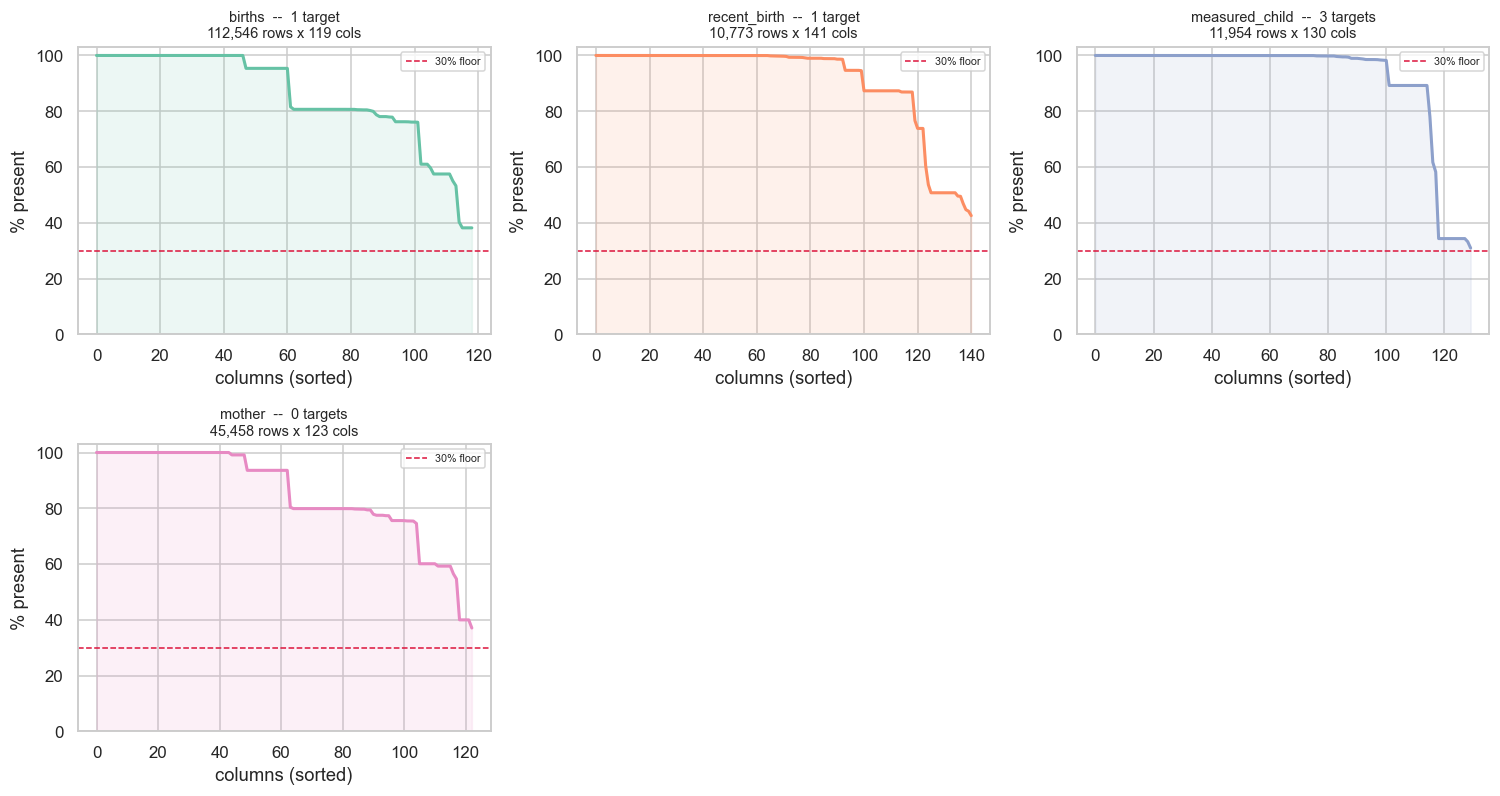

4 cohorts plotted, carrying 5 targets in total.


In [16]:
# Coverage inside every cohort. The grid is derived from len(cohorts) rather
# than hard-coded: an earlier version created four axes and zipped them against
# a seven-item dict, and zip() stops at the shorter argument, so three cohorts
# were dropped without a warning.
n = len(cohorts)
ncol = min(3, n)
nrow = -(-n // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.7 * nrow),
                         squeeze=False)
flat = axes.flatten()

carried = {c: sum(1 for s in REGISTRY.values() if s["cohort"] == c)
           for c in cohorts}

for ax, (name, c) in zip(flat, cohorts.items()):
    cov = c.notna().mean().sort_values(ascending=False)
    colour = sns.color_palette("Set2")[list(cohorts).index(name) % 8]
    ax.plot(range(len(cov)), cov.values * 100, lw=2, color=colour)
    ax.fill_between(range(len(cov)), 0, cov.values * 100, alpha=0.12,
                    color=colour)
    ax.axhline(30, color="crimson", ls="--", lw=1, label="30% floor")
    tgt = carried[name]
    ax.set_title(f"{name}  --  {tgt} target{'' if tgt == 1 else 's'}\n"
                 f"{len(c):,} rows x {c.shape[1]} cols", fontsize=9.5)
    ax.set_xlabel("columns (sorted)")
    ax.set_ylabel("% present")
    ax.set_ylim(0, 103)
    ax.legend(fontsize=7)

for ax in flat[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

print(f"{n} cohorts plotted, carrying {sum(carried.values())} targets in total.")
assert sum(carried.values()) == len(REGISTRY)

**What this shows.** Column coverage inside each of the five cohorts, with the
number of prediction targets each one supports.

Within a cohort, coverage is a **flat high plateau** with a short tail —
completely unlike the bimodal mess in section 3. That is the signature of a
correctly-defined universe, and it is what makes a missingness filter safe to
apply here and unsafe to apply globally.

**`cohort_mother` carries no targets, and that is deliberate.** It is the
one-row-per-woman view feeding the equity and geography sections of `01b`, and
the source of the mother-level features the other four inherit. Counting a woman
once there and once per birth elsewhere is exactly why it is a separate file.

The remaining four carry six targets between them: births 1, recent_birth 1,
measured_child 3, immunization 1. The assertion under the figure fails if that
ever stops summing to the registry.

# 11. Save

In [17]:
def save(obj, stem):
    """Write both formats.

    Parquet is the one 01b, 02 and 03 read: it preserves dtypes, so a nullable
    integer stays an integer instead of coming back as float with the nulls
    turned into NaN. The CSV is a readable mirror for inspection outside Python.

    Both are written on every run deliberately. Writing only the parquet leaves
    whatever CSV happened to exist from an earlier panel sitting next to it,
    and a stale CSV that still opens cleanly is worse than no CSV at all.
    """
    obj.to_parquet(COHORT_DIR / f"{stem}.parquet", index=False)
    obj.to_csv(COHORT_DIR / f"{stem}.csv", index=False)
    return f"{stem}.parquet + .csv"


for name, c in cohorts.items():
    print(f"  {save(c, 'cohort_' + name):42s} {len(c):7,} rows x {c.shape[1]:4d} cols")

registry_out = {
    t: {
        "cohort": s["cohort"],
        "phase": s["phase"],
        "kind": s["kind"],
        "positive_label": s["positive_label"],
        "n_features": len(s["features"]),
        "features": s["features"],
        "blacklist": s["blacklist"],
    }
    for t, s in REGISTRY.items()
}
(DATA_DIR / "target_registry.json").write_text(
    json.dumps(registry_out, indent=2), encoding="utf-8")
print(f"\n  target_registry.json   {len(registry_out)} targets")

  cohort_births.parquet + .csv               112,546 rows x  119 cols


  cohort_recent_birth.parquet + .csv          10,773 rows x  141 cols


  cohort_measured_child.parquet + .csv        11,954 rows x  130 cols


  cohort_mother.parquet + .csv                45,458 rows x  123 cols

  target_registry.json   5 targets


# 12. Handover

Four cohorts carry the **5 targets**. Three of them own targets; `cohort_mother`
owns none — it is the one-row-per-woman view, used for the equity and geography
sections of `01b` and as the source of the mother-level features the other three
inherit.

| Cohort | Rows | Targets | n |
|---|---|---|---|
| `cohort_births` | 112,546 | neonatal death | 1 |
| `cohort_mother` | 45,458 | — *features and EDA only* | 0 |
| `cohort_measured_child` | 11,954 | stunting, severe stunting, underweight | 3 |
| `cohort_recent_birth` | 10,773 | facility delivery | 1 |

Each is written twice, as `.parquet` and `.csv`. The notebooks read the parquet,
because CSV cannot round-trip a nullable integer — the nulls come back as `NaN`
and the column comes back as float. The CSV is the readable mirror.

**Carried forward into notebook 02:**

- `mother_id` on every cohort → `GroupKFold`, never a random split. This matters
  most on `cohort_births`, where 90% of rows belong to a mother who appears more
  than once.
- `survey_round` → a stratifier and a metadata column, **never a feature**; a
  synthetic patient cannot meaningfully belong to a survey year
- `weight` (`v005/1e6`, renormalised within round) → for any reported
  prevalence, not for model fitting
- `eligible_*` flags → censoring windows for the mortality target
- `target_registry.json` → features and blacklist per target, already resolved
- both file formats per cohort → parquet for the notebooks, CSV to open anywhere
  else

**All five targets are measured in both survey rounds.** That was not true of
earlier versions of the panel, and it removes a whole class of caveat: every
model trains on the pooled sample, and no result needs a footnote about which
survey year it describes.

**Why these five, and not the other ten:**

The panel was cut from fifteen after measuring what was actually learnable. The
reasons are stated rather than implied:

- **Not predictable.** `child_fever` (ROC-AUC 0.573, recall 0.004), `wasted`
  (0.588, recall 0.005), `child_diarrhoea` (0.621). These are two-week recall
  windows, and acute infection is close to universally distributed — diarrhoea
  moves 0.4 percentage points across the entire wealth range. There is no stable
  signal to learn.
- **Predictable, but not of the outcome.** `incomplete_immunization` reported
  0.823, and 0.944 once the child's age was available. Every child under six
  months is "incomplete" because the schedule is not finished, so the model was
  predicting age. Restricted to 12–23 months with age removed — the denominator
  DHS itself uses — it falls to **0.59**. The derivation is correct (11.9%
  incomplete against a published 88.3% coverage) but the outcome is not learnable
  once it stops standing in for something else.
- **Not actionable.** `csection` predicts well (0.871) but records a clinician's
  decision rather than a patient's risk. Retained as a descriptive equity
  indicator.
- **Definitionally unsound.** `child_ari` used only the short-rapid-breathing
  question and omitted the chest-related qualifier the DHS indicator requires,
  giving 12.8% against a published 3.0%.
- **Contaminated or too thin.** `pregnancy_loss` (0.625) is driven by recall
  intensity — reported loss falls from 14.7% within two years to 8.8% beyond
  twenty. `stillbirth` (0.616) is 2022-only and identical to `pregnancy_loss` on
  their shared support. `small_size_at_birth` reached 0.709 but recall 0.152,
  finding 15% of small babies. `no_immunization` rests on 354 positives and
  carries the same age artefact as its parent.

Three of the ten were removed for reasons that no amount of tuning would have
fixed, and two were removed *because* they scored well. That distinction is the
substance of the target-selection argument.

**Known limits, stated up front:**

- **Maternal and child anaemia are impossible.** `v453`–`v460` and `hw53`–`hw58`
  are empty in both rounds; the biomarker recode was never merged.
- No blood pressure or glucose, so clinical pregnancy complications
  (pre-eclampsia, gestational diabetes, haemorrhage, sepsis) have no ground
  truth here and no model predicts them.
- `high_risk_pregnancy` is a **rule-based composite**, used as a feature and a
  stratifier, never as a prediction target — a classifier trained on it would
  only relearn its own definition.
- `cohort_measured_child` is **65.7% from the 2017-18 round**, because that
  survey measured 7,849 children against 2022's 4,105. The three nutrition
  models therefore learn mostly from 2017-18 conditions.
- The three nutrition targets are correlated with each other (φ = 0.46 between
  stunting and severe stunting, 0.51 between stunting and underweight). They are
  three views of child undernutrition rather than three independent problems, and
  results should be read that way.
- Every record is retrospective, so covariates describe the mother **at
  interview**, not at the time of an older pregnancy. Associations, not causal
  effects.